In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Mounted at /content/drive
Libraries loaded ✅


In [ ]:
import os
path = "/content/drive/MyDrive/predictive_maintenance/"
print(os.listdir(path))

['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv', 'feature_names.csv', 'xgb_model.pkl', 'rf_model.pkl']


In [ ]:
path = "/content/drive/MyDrive/predictive_maintenance/"

X_test  = pd.read_csv(path + "X_test.csv").values
y_test  = pd.read_csv(path + "y_test.csv").values.ravel()

# Load feature names WITHOUT adding Power and Temp_diff again
# They are already saved inside the CSV from preprocessing
feature_names = pd.read_csv(path + "feature_names.csv").iloc[:,0].tolist()

xgb = joblib.load(path + "xgb_model.pkl")
rf  = joblib.load(path + "rf_model.pkl")

print("Feature names:", feature_names)
print("Feature count:", len(feature_names))
print("Model feature count:", len(xgb.feature_importances_))
print("\nModel & data loaded ✅")

Feature names: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power', 'Temp_diff']
Feature count: 8
Model feature count: 8

Model & data loaded ✅


In [ ]:
xgb_preds = xgb.predict(X_test)

print("=" * 45)
print("       XGBoost - Full Evaluation Report")
print("=" * 45)
print(classification_report(y_test, xgb_preds,
      target_names=["No Failure", "Failure"]))

       XGBoost - Full Evaluation Report
              precision    recall  f1-score   support

  No Failure       0.97      0.96      0.97      1933
     Failure       0.96      0.97      0.97      1932

    accuracy                           0.97      3865
   macro avg       0.97      0.97      0.97      3865
weighted avg       0.97      0.97      0.97      3865



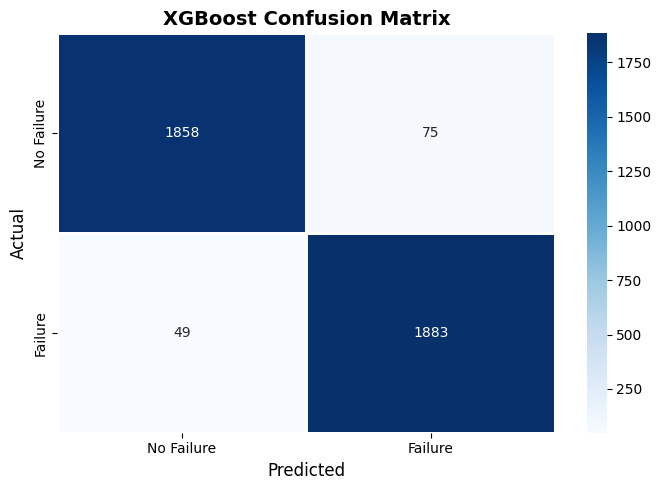


True Positives  (Correctly predicted failures): 1883
True Negatives  (Correctly predicted no failure): 1858
False Positives (False alarms): 75
False Negatives (Missed failures): 49


In [ ]:
cm = confusion_matrix(y_test, xgb_preds)
labels = ["No Failure", "Failure"]

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=1, linecolor='white')

plt.title("XGBoost Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.tight_layout()
plt.show()

# Print key numbers
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (Correctly predicted failures): {tp}")
print(f"True Negatives  (Correctly predicted no failure): {tn}")
print(f"False Positives (False alarms): {fp}")
print(f"False Negatives (Missed failures): {fn}")

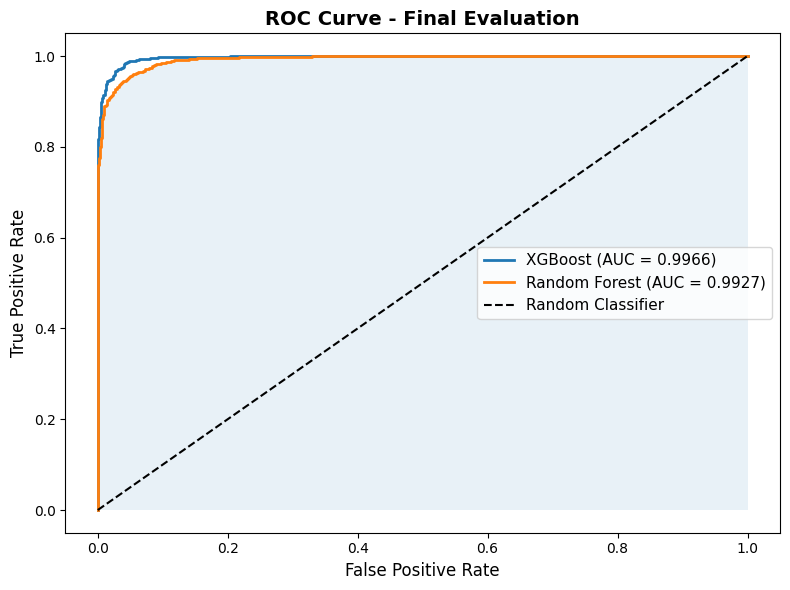

In [ ]:
xgb_proba = xgb.predict_proba(X_test)[:,1]
rf_proba  = rf.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,6))

for name, proba in [("XGBoost", xgb_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0,1], [0,1], 'k--', label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Final Evaluation", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

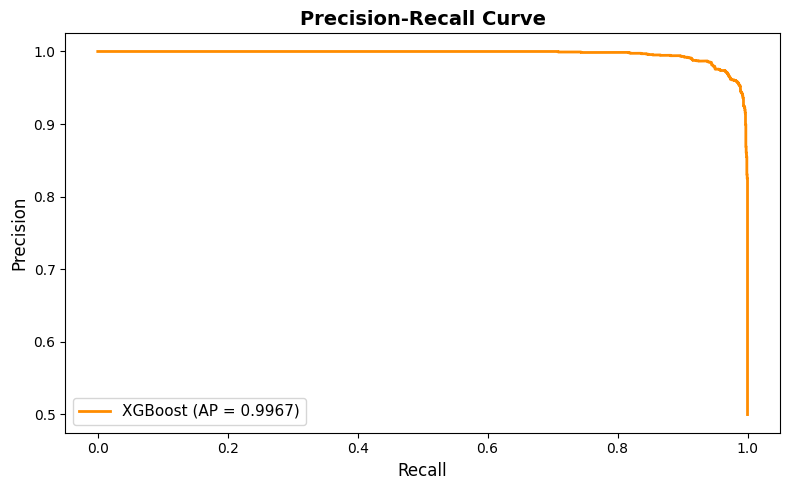

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, xgb_proba)
ap = average_precision_score(y_test, xgb_proba)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, color='darkorange',
         linewidth=2, label=f"XGBoost (AP = {ap:.4f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
print("Feature names count:", len(feature_names))
print("Model features count:", len(xgb.feature_importances_))
print("\nFeature names list:")
print(feature_names)

Feature names count: 10
Model features count: 8

Feature names list:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power', 'Temp_diff', 'Power', 'Temp_diff']


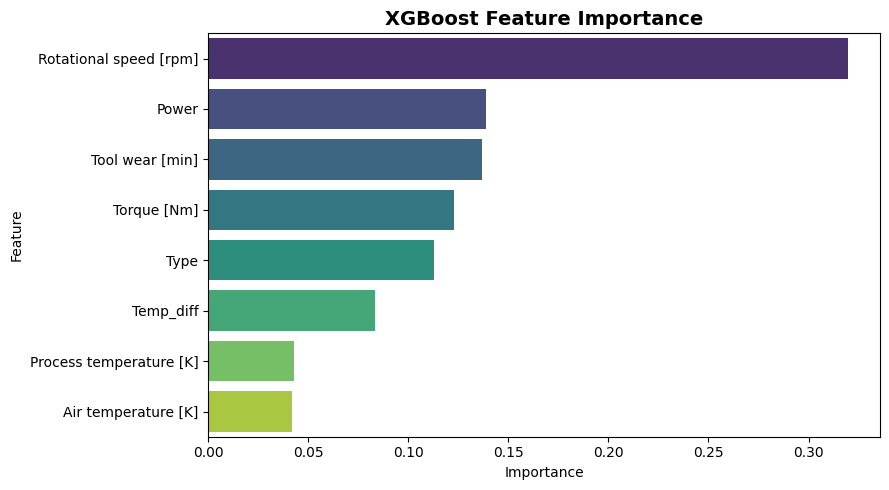

                   Feature  Importance
3   Rotational speed [rpm]    0.319711
6                    Power    0.139076
5          Tool wear [min]    0.137102
4              Torque [Nm]    0.122758
0                     Type    0.112739
7                Temp_diff    0.083458
2  Process temperature [K]    0.043057
1      Air temperature [K]    0.042099


In [ ]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x='Importance', y='Feature',
            data=importance_df, palette='viridis')
plt.title("XGBoost Feature Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(importance_df)

In [ ]:
summary = {
    "Model": "XGBoost",
    "ROC_AUC": round(roc_auc_score(y_test, xgb_proba), 4),
    "Average_Precision": round(ap, 4),
    "True_Positives": int(tp),
    "False_Negatives": int(fn),
    "False_Positives": int(fp)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(path + "model_summary.csv", index=False)

print("Final Summary:")
print(summary_df.to_string(index=False))
print("\nSummary saved to Google Drive ✅")

Final Summary:
  Model  ROC_AUC  Average_Precision  True_Positives  False_Negatives  False_Positives
XGBoost   0.9966             0.9967            1883               49               75

Summary saved to Google Drive ✅


In [ ]:
summary = {
    "Model": "XGBoost",
    "ROC_AUC": round(roc_auc_score(y_test, xgb_proba), 4),
    "Average_Precision": round(ap, 4),
    "True_Positives": int(tp),
    "False_Negatives": int(fn),
    "False_Positives": int(fp)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(path + "model_summary.csv", index=False)

print("Final Summary:")
print(summary_df.to_string(index=False))
print("\nSummary saved to Google Drive ✅")

Final Summary:
  Model  ROC_AUC  Average_Precision  True_Positives  False_Negatives  False_Positives
XGBoost   0.9966             0.9967            1883               49               75

Summary saved to Google Drive ✅
